In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

In [5]:
from google.colab import files

uploaded = files.upload()

DATASET_PATH = next(iter(uploaded.keys()))

print("Dataset loaded:", DATASET_PATH)

Saving Monthly_Food_Retail_Prices.csv to Monthly_Food_Retail_Prices.csv
Dataset loaded: Monthly_Food_Retail_Prices.csv


In [6]:
MONTH_TO_SEASON = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Summer", 4: "Summer", 5: "Summer",
    6: "Monsoon", 7: "Monsoon", 8: "Monsoon", 9: "Monsoon",
    10: "Post-Monsoon", 11: "Post-Monsoon"
}

class CommodityPriceAnalyzer:
    def __init__(self, path):
        self.path = path
        self.raw = None
        self.data = None
        self.report = {}

    def load_data(self):
        self.raw = pd.read_csv(
            self.path,
            dtype={
                "State": "string", "Centre": "string", "Commodity": "string",
                "Variety": "string", "Unit": "string", "Category": "string",
                "Date": "string"
            }
        )
        self.data = self.raw.copy()
        self.report["rows_loaded"] = len(self.data)
        self.report["columns_loaded"] = list(self.data.columns)
        return self.data

    def clean_data(self):
        df = self.data
        rows_before = len(df)
        df = df.drop_duplicates()
        duplicates_removed = rows_before - len(df)

        text_cols = [c for c in ["State", "Centre", "Commodity", "Variety", "Unit"] if c in df.columns]
        for c in text_cols:
            df[c] = df[c].str.strip()

        missing_commodity = int(df["Commodity"].isna().sum()) if "Commodity" in df.columns else 0
        if "Commodity" in df.columns:
            df = df[df["Commodity"].notna()]

        if "Variety" in df.columns:
            df["Variety"] = df["Variety"].fillna("Not Specified")

        price_col = "Retail Price" if "Retail Price" in df.columns else None
        if price_col:
            df[price_col] = pd.to_numeric(df[price_col], errors="coerce")
            df = df[(df[price_col].isna()) | (df[price_col] > 0)]

        if "Category" in df.columns and df["Category"].nunique(dropna=True) <= 1:
            df = df.drop(columns=["Category"])

        self.report["duplicates_removed"] = int(duplicates_removed)
        self.report["missing_commodity_rows_dropped"] = missing_commodity
        self.report["rows_after_cleaning"] = len(df)
        self.data = df
        return self.data

    def prepare_columns(self):
        df = self.data
        if "Date" in df.columns:
            df["Date_Parsed"] = pd.to_datetime(df["Date"], format="%b-%Y", errors="coerce")
            df["Year"] = df["Date_Parsed"].dt.year
            df["Month"] = df["Date_Parsed"].dt.month
            df["Season"] = df["Month"].map(MONTH_TO_SEASON)
        if "Retail Price" in df.columns:
            df["Price_Missing"] = df["Retail Price"].isna()
        self.data = df
        return self.data

    def compute_statistics(self):
        stats = {}
        if "Retail Price" in self.data.columns:
            df = self.data.dropna(subset=["Retail Price"])
            prices = df["Retail Price"].to_numpy()
            stats["mean"] = float(np.mean(prices))
            stats["median"] = float(np.median(prices))
            stats["std"] = float(np.std(prices))
            stats["p10"] = float(np.percentile(prices, 10))
            stats["p90"] = float(np.percentile(prices, 90))
            stats["p99"] = float(np.percentile(prices, 99))
            q1, q3 = np.percentile(prices, [25, 75])
            iqr = q3 - q1
            stats["outlier_low"] = float(q1 - 1.5 * iqr)
            stats["outlier_high"] = float(q3 + 1.5 * iqr)
        self.report["global_statistics"] = stats
        return stats

    def generate_analysis_tables(self):
        tables = {}
        if "Retail Price" not in self.data.columns:
            self.report["tables_generated"] = []
            return tables
        df = self.data.dropna(subset=["Retail Price"])

        if "Commodity" in df.columns:
            commodity_stats = df.groupby("Commodity")["Retail Price"].agg(
                ["mean", "median", "std", "min", "max", "count"]
            )
            commodity_stats["price_range"] = commodity_stats["max"] - commodity_stats["min"]
            commodity_stats["coefficient_of_variation"] = (
                commodity_stats["std"] / commodity_stats["mean"]
            )
            tables["commodity_stats"] = commodity_stats.sort_values("mean", ascending=False)

        if "State" in df.columns:
            tables["state_stats"] = (
                df.groupby("State")["Retail Price"].agg(["mean", "median", "count"])
                .sort_values("mean", ascending=False)
            )

        if "Season" in df.columns:
            tables["season_stats"] = (
                df.groupby("Season")["Retail Price"].agg(["mean", "median", "count"])
                .reindex(["Winter", "Summer", "Monsoon", "Post-Monsoon"])
            )

        if "Year" in df.columns:
            tables["year_stats"] = df.groupby("Year")["Retail Price"].agg(["mean", "median", "count"])

        if "State" in df.columns and "Commodity" in df.columns:
            tables["state_commodity_pivot"] = pd.pivot_table(
                df, index="State", columns="Commodity", values="Retail Price", aggfunc="mean"
            )

        if "Year" in df.columns and "Commodity" in df.columns:
            tables["year_commodity_pivot"] = pd.pivot_table(
                df, index="Year", columns="Commodity", values="Retail Price", aggfunc="mean"
            )

        self.report["tables_generated"] = list(tables.keys())
        return tables

In [7]:
analyzer = CommodityPriceAnalyzer(DATASET_PATH)
analyzer.load_data()
print(analyzer.data.shape)
print(sorted(analyzer.data.columns.tolist()))
analyzer.data.info()

(1147446, 8)
['Category', 'Centre', 'Commodity', 'Date', 'Retail Price', 'State', 'Unit', 'Variety']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1147446 entries, 0 to 1147445
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   State         1147446 non-null  string 
 1   Centre        1147446 non-null  string 
 2   Commodity     1137726 non-null  string 
 3   Variety       941868 non-null   string 
 4   Unit          1147446 non-null  string 
 5   Category      1147446 non-null  string 
 6   Date          1147446 non-null  string 
 7   Retail Price  578525 non-null   float64
dtypes: float64(1), string(7)
memory usage: 70.0 MB


In [8]:
missing_summary = pd.DataFrame({
    "missing_count": analyzer.data.isna().sum(),
    "missing_pct": (analyzer.data.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)
missing_summary

,missing_count,missing_pct
Retail Price,568921,49.58
Variety,205578,17.92
Commodity,9720,0.85
Centre,0,0.00
State,0,0.00
Unit,0,0.00
Category,0,0.00
Date,0,0.00


In [9]:
duplicate_rows = analyzer.data.duplicated().sum()
print(duplicate_rows)
analyzer.data.describe(include="all").transpose()

2270


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State,1147446,30,Tamil Nadu,82377,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Centre,1147446,86,Vishakhapatnam,13851,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Commodity,1137726,46,Rice,61965,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variety,941868,30,FAQ,175689,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unit,1147446,11,Kg.,757917,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,1147446,1,Food,1147446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,1147446,243,JAN-2001,4722,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Retail Price,578525.0,NaN,NaN,NaN,79.691448,148.780859,0.5,18.0,35.0,80.0,20045.0


In [10]:
analyzer.clean_data()
analyzer.prepare_columns()
print(analyzer.report["duplicates_removed"])
print(analyzer.report["missing_commodity_rows_dropped"])
print(analyzer.report["rows_after_cleaning"])
analyzer.data.dtypes

/tmp/ipykernel_1564/2409410451.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[c] = df[c].str.strip()


2270
7450
1137726


,0
State,string[python]
Centre,string[python]
Commodity,string[python]
Variety,string[python]
Unit,string[python]
Date,string[python]
Retail Price,float64
Date_Parsed,datetime64[ns]
Year,int32
Month,int32


In [11]:
analyzer.data.head(10)

,State,Centre,Commodity,Variety,Unit,Date,Retail Price,Date_Parsed,Year,Month,Season,Price_Missing
0,Andhra Pradesh,Chittoor,Moong,Split,Kg.,JAN-2001,24.0,2001-01-01,2001,1,Winter,False
1,Andhra Pradesh,Guntur,Moong,Split,Kg.,JAN-2001,26.0,2001-01-01,2001,1,Winter,False
2,Andhra Pradesh,Kurnool,Moong,Split,Kg.,JAN-2001,25.5,2001-01-01,2001,1,Winter,False
3,Andhra Pradesh,Vishakhapatnam,Moong,Split,Kg.,JAN-2001,NaN,2001-01-01,2001,1,Winter,True
4,Arunachal Pradesh,Itanagar,Moong,Split,Kg.,JAN-2001,NaN,2001-01-01,2001,1,Winter,True
5,Assam,Dibrugarh,Moong,Split,Kg.,JAN-2001,NaN,2001-01-01,2001,1,Winter,True
6,Assam,Dispur,Moong,Split,Kg.,JAN-2001,NaN,2001-01-01,2001,1,Winter,True
7,Assam,Guwahati,Moong,Split,Kg.,JAN-2001,NaN,2001-01-01,2001,1,Winter,True
8,Assam,Silchar,Moong,Split,Kg.,JAN-2001,NaN,2001-01-01,2001,1,Winter,True
9,Bihar,Gaya,Moong,Split,Kg.,JAN-2001,NaN,2001-01-01,2001,1,Winter,True


In [12]:
stats = analyzer.compute_statistics()
{k: round(v, 3) for k, v in stats.items()}

{'mean': 79.733,
 'median': 35.0,
 'std': 148.982,
 'p10': 10.0,
 'p90': 180.0,
 'p99': 740.0,
 'outlier_low': -75.0,
 'outlier_high': 173.0}

In [13]:
tables = analyzer.generate_analysis_tables()
sorted(tables.keys())

['commodity_stats',
 'season_stats',
 'state_commodity_pivot',
 'state_stats',
 'year_commodity_pivot',
 'year_stats']

In [14]:
if "commodity_stats" in tables:
    tables["commodity_stats"].round(2).head(15)

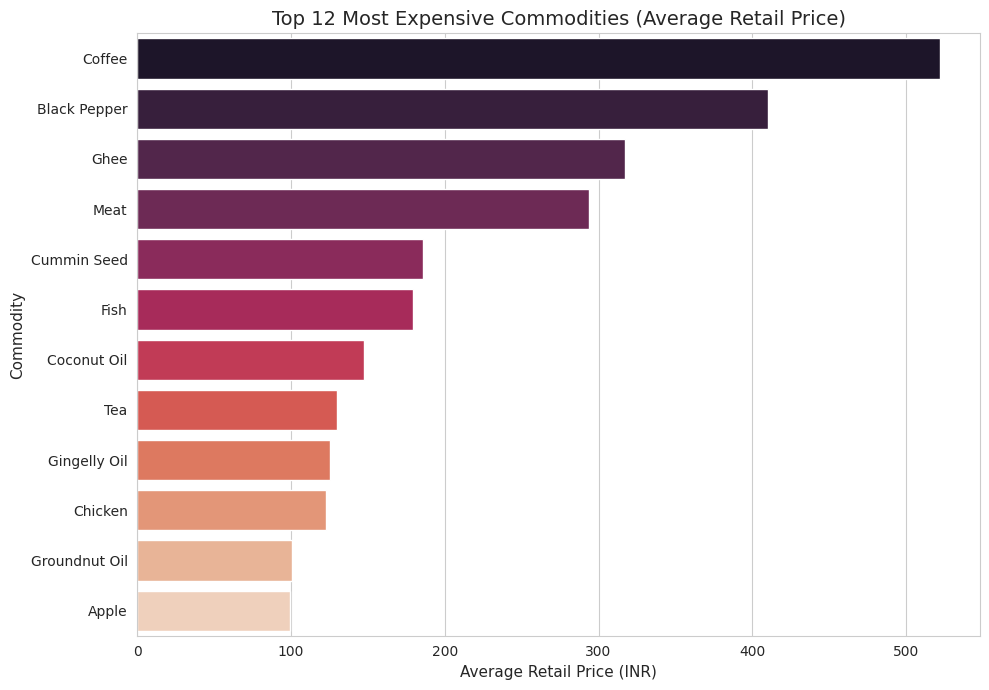

In [15]:
if "commodity_stats" in tables:
    top_expensive = tables["commodity_stats"].sort_values("mean", ascending=False).head(12)
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(x=top_expensive["mean"], y=top_expensive.index, hue=top_expensive.index,
                palette="rocket", legend=False, ax=ax)
    ax.set_title("Top 12 Most Expensive Commodities (Average Retail Price)")
    ax.set_xlabel("Average Retail Price (INR)")
    ax.set_ylabel("Commodity")
    plt.tight_layout()
    plt.show()

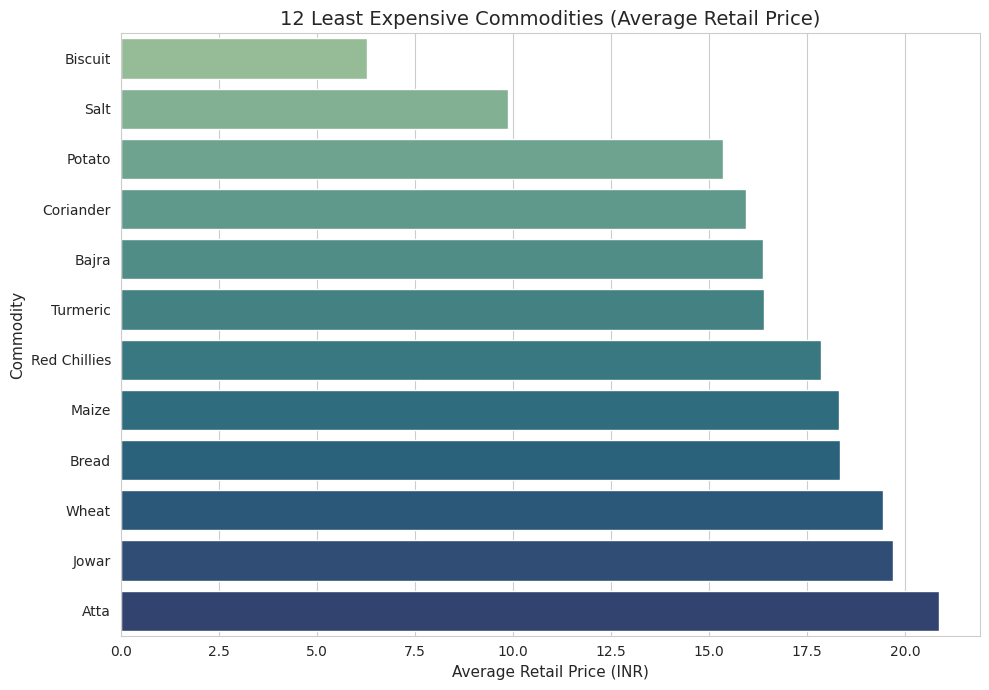

In [16]:
if "commodity_stats" in tables:
    cheapest = tables["commodity_stats"].sort_values("mean", ascending=True).head(12)
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(x=cheapest["mean"], y=cheapest.index, hue=cheapest.index,
                palette="crest", legend=False, ax=ax)
    ax.set_title("12 Least Expensive Commodities (Average Retail Price)")
    ax.set_xlabel("Average Retail Price (INR)")
    ax.set_ylabel("Commodity")
    plt.tight_layout()
    plt.show()

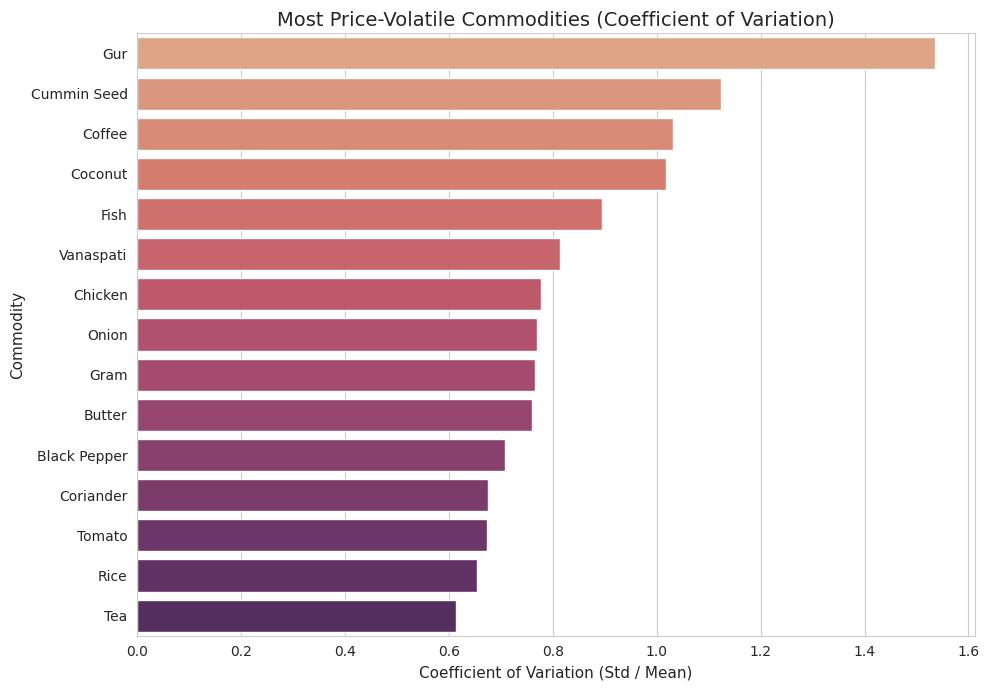

In [17]:
if "commodity_stats" in tables:
    volatility_ranked = tables["commodity_stats"][tables["commodity_stats"]["count"] >= 200]
    volatility_ranked = volatility_ranked.sort_values("coefficient_of_variation", ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(x=volatility_ranked["coefficient_of_variation"], y=volatility_ranked.index,
                hue=volatility_ranked.index, palette="flare", legend=False, ax=ax)
    ax.set_title("Most Price-Volatile Commodities (Coefficient of Variation)")
    ax.set_xlabel("Coefficient of Variation (Std / Mean)")
    ax.set_ylabel("Commodity")
    plt.tight_layout()
    plt.show()
    volatility_ranked.round(3)

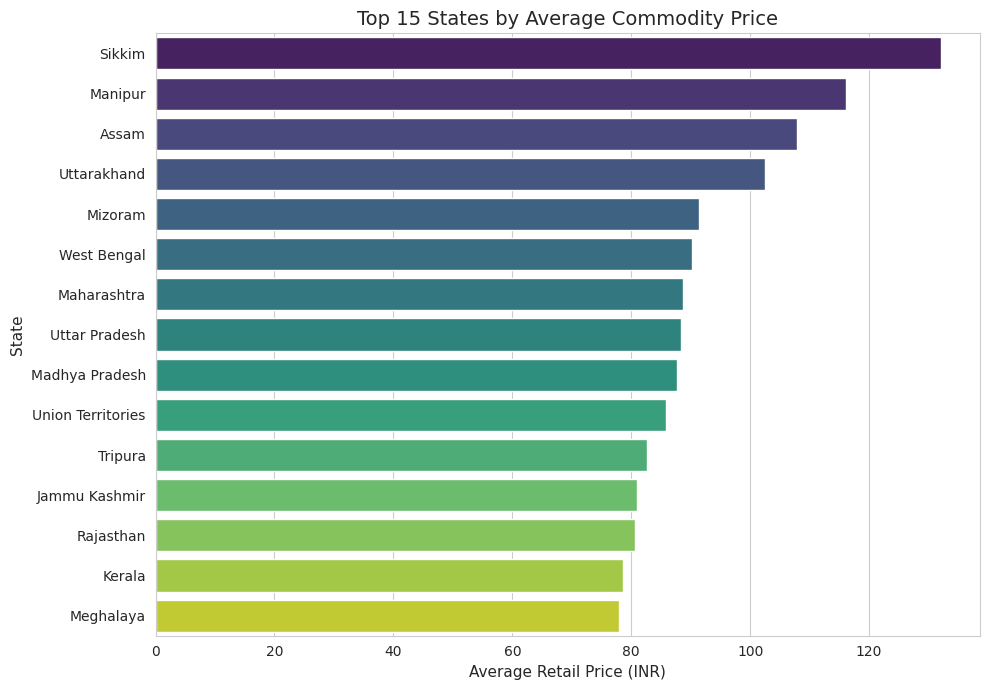

In [18]:
if "state_stats" in tables:
    top_states = tables["state_stats"].head(15)
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(x=top_states["mean"], y=top_states.index, hue=top_states.index,
                palette="viridis", legend=False, ax=ax)
    ax.set_title("Top 15 States by Average Commodity Price")
    ax.set_xlabel("Average Retail Price (INR)")
    ax.set_ylabel("State")
    plt.tight_layout()
    plt.show()

In [19]:
if "commodity_stats" in tables:
    frequent_commodities = [
        c for c in tables["commodity_stats"].sort_values("count", ascending=False).head(6).index
    ]
    print(frequent_commodities)

['Rice', 'Gram', 'Milk', 'Salt', 'Tea', 'Fish']


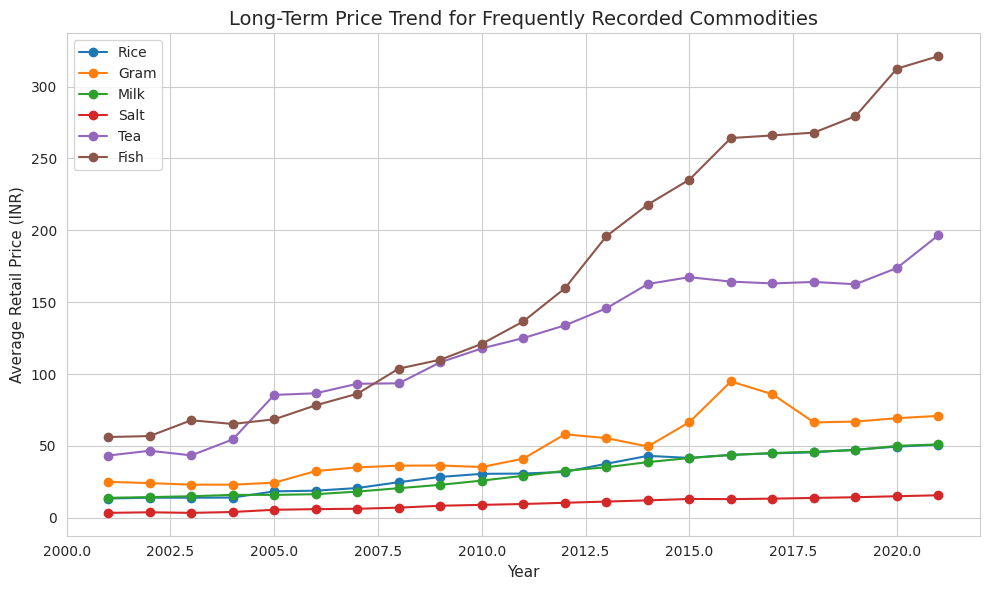

In [20]:
if "year_commodity_pivot" in tables and "commodity_stats" in tables:
    trend_data = tables["year_commodity_pivot"][frequent_commodities]
    fig, ax = plt.subplots()
    for commodity in frequent_commodities:
        ax.plot(trend_data.index, trend_data[commodity], marker="o", label=commodity)
    ax.set_title("Long-Term Price Trend for Frequently Recorded Commodities")
    ax.set_xlabel("Year")
    ax.set_ylabel("Average Retail Price (INR)")
    ax.legend()
    plt.tight_layout()
    plt.show()

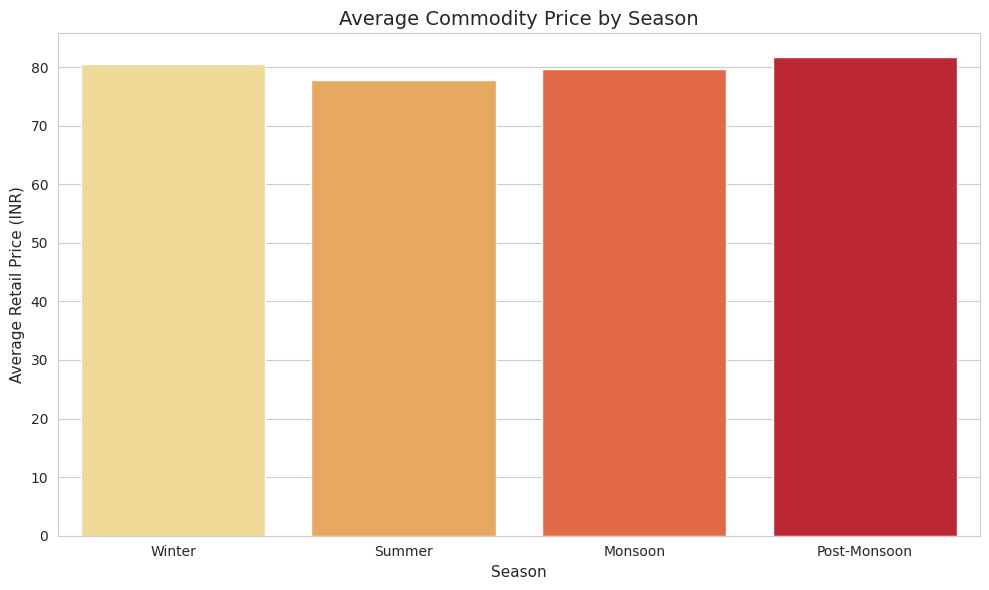

In [21]:
if "season_stats" in tables:
    fig, ax = plt.subplots()
    seasons = tables["season_stats"].dropna(how="all")
    sns.barplot(x=seasons.index, y=seasons["mean"], hue=seasons.index,
                palette="YlOrRd", legend=False, ax=ax)
    ax.set_title("Average Commodity Price by Season")
    ax.set_xlabel("Season")
    ax.set_ylabel("Average Retail Price (INR)")
    plt.tight_layout()
    plt.show()

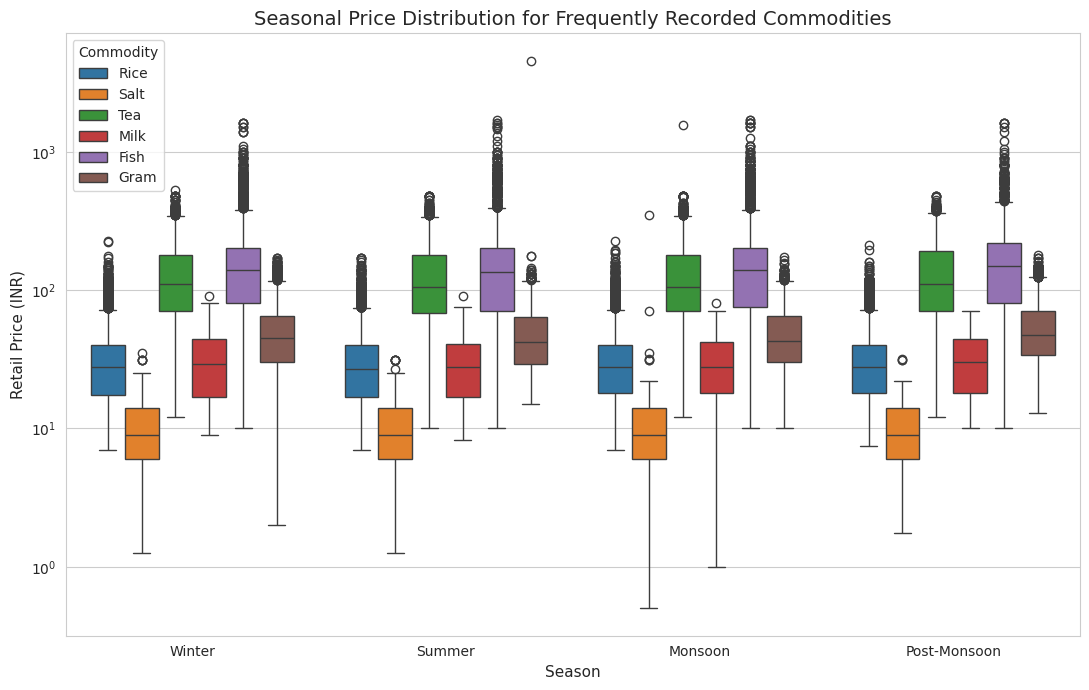

In [22]:
if "Season" in analyzer.data.columns:
    clean_prices = analyzer.data.dropna(subset=["Retail Price"])
    subset = clean_prices[clean_prices["Commodity"].isin(frequent_commodities)]
    fig, ax = plt.subplots(figsize=(11, 7))
    order = ["Winter", "Summer", "Monsoon", "Post-Monsoon"]
    sns.boxplot(data=subset, x="Season", y="Retail Price", hue="Commodity",
                order=order, ax=ax)
    ax.set_title("Seasonal Price Distribution for Frequently Recorded Commodities")
    ax.set_xlabel("Season")
    ax.set_ylabel("Retail Price (INR)")
    ax.set_yscale("log")
    plt.tight_layout()
    plt.show()

In [23]:
if "year_commodity_pivot" in tables:
    pivot = tables["year_commodity_pivot"]
    valid_years = pivot.dropna(how="all").index
    first_years = pivot.loc[valid_years[:3]].mean()
    last_years = pivot.loc[valid_years[-3:]].mean()
    pct_change = ((last_years - first_years) / first_years) * 100
    pct_change_df = pct_change.dropna().sort_values(ascending=False)
    pct_change_df = pd.DataFrame({"pct_change": pct_change_df})
    pct_change_df.round(1).head(15)

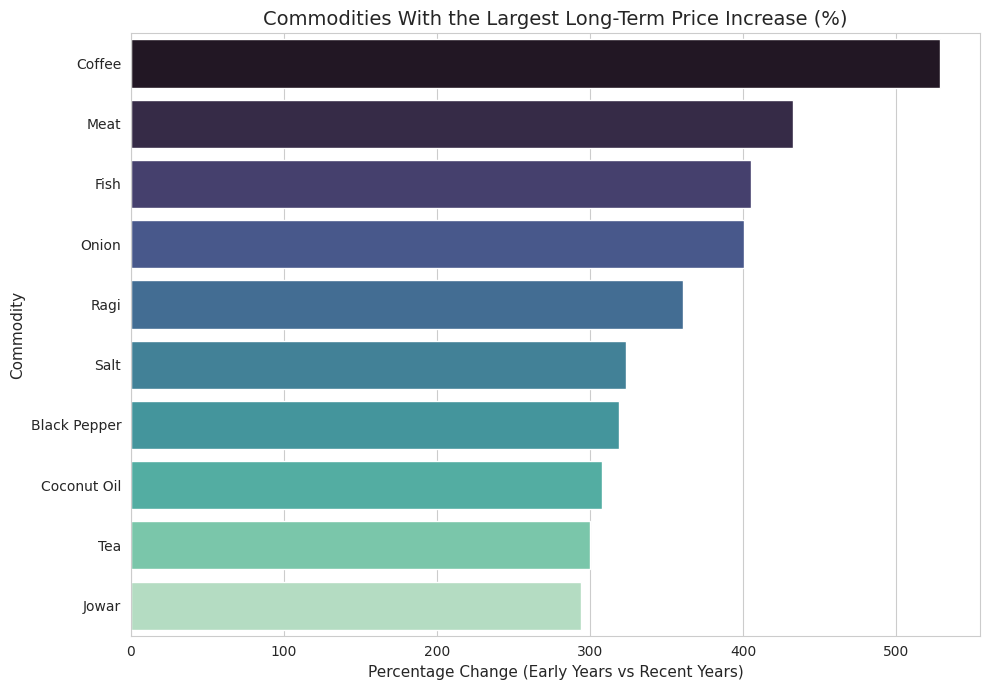

In [24]:
if "year_commodity_pivot" in tables:
    top_movers = pct_change_df.head(10)
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(x=top_movers["pct_change"], y=top_movers.index, hue=top_movers.index,
                palette="mako", legend=False, ax=ax)
    ax.set_title("Commodities With the Largest Long-Term Price Increase (%)")
    ax.set_xlabel("Percentage Change (Early Years vs Recent Years)")
    ax.set_ylabel("Commodity")
    plt.tight_layout()
    plt.show()

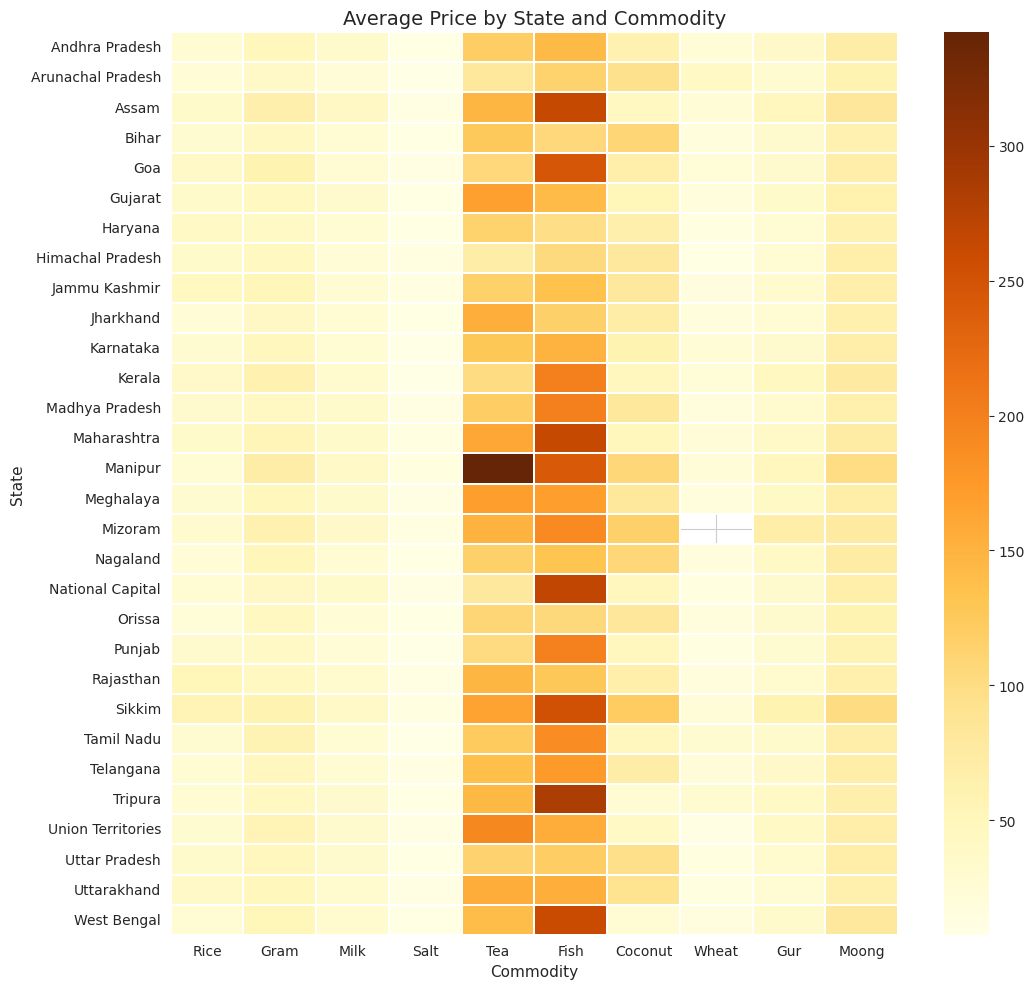

In [25]:
if "state_commodity_pivot" in tables:
    top_commodities_for_heatmap = [
        c for c in tables["commodity_stats"].sort_values("count", ascending=False).head(10).index
    ]
    heatmap_data = tables["state_commodity_pivot"][top_commodities_for_heatmap]
    heatmap_data = heatmap_data.dropna(thresh=5)
    fig, ax = plt.subplots(figsize=(11, 10))
    sns.heatmap(heatmap_data, cmap="YlOrBr", ax=ax, linewidths=0.3)
    ax.set_title("Average Price by State and Commodity")
    ax.set_xlabel("Commodity")
    ax.set_ylabel("State")
    plt.tight_layout()
    plt.show()

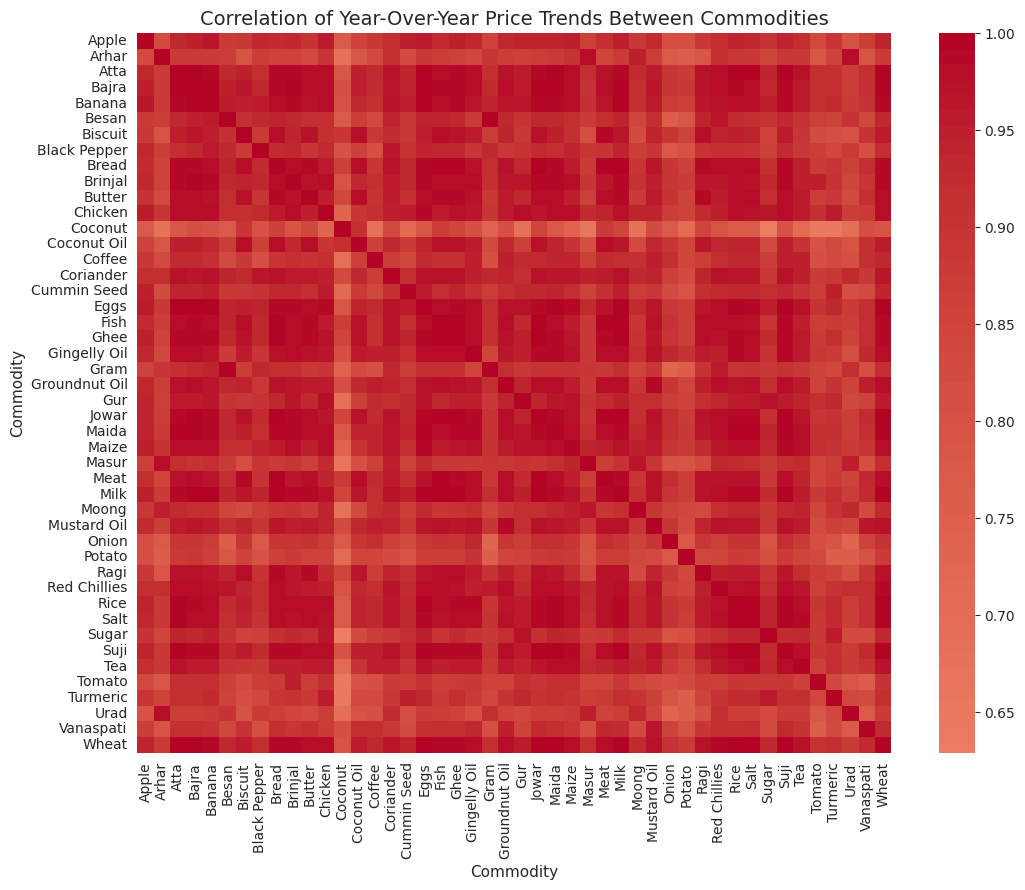

In [26]:
if "year_commodity_pivot" in tables:
    trend_corr = tables["year_commodity_pivot"].corr()
    strong_commodities = [
        c for c in trend_corr.columns
        if tables["commodity_stats"].loc[c, "count"] >= 500
    ] if "commodity_stats" in tables else list(trend_corr.columns)
    trend_corr_subset = trend_corr.loc[strong_commodities, strong_commodities]
    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(trend_corr_subset, cmap="coolwarm", center=0, ax=ax, annot=False)
    ax.set_title("Correlation of Year-Over-Year Price Trends Between Commodities")
    plt.tight_layout()
    plt.show()

In [27]:
if "Commodity" in analyzer.data.columns and "commodity_stats" in tables:
    priced_df = analyzer.data.dropna(subset=["Retail Price"])
    commodity_lookup = tables["commodity_stats"][["mean", "std"]].rename(
        columns={"mean": "commodity_mean", "std": "commodity_std"}
    )
    merged = priced_df.merge(commodity_lookup, on="Commodity", how="left")
    merged["price_zscore"] = (
        (merged["Retail Price"] - merged["commodity_mean"]) / merged["commodity_std"]
    )
    outliers = merged[merged["price_zscore"].abs() > 4]
    print(len(outliers))
    print(round(len(outliers) / len(merged) * 100, 4))
    outlier_cols = [c for c in ["State", "Centre", "Commodity", "Date", "Retail Price", "price_zscore"]
                     if c in outliers.columns]
    outliers.sort_values("price_zscore", ascending=False)[outlier_cols].head(20)

1671
0.2912


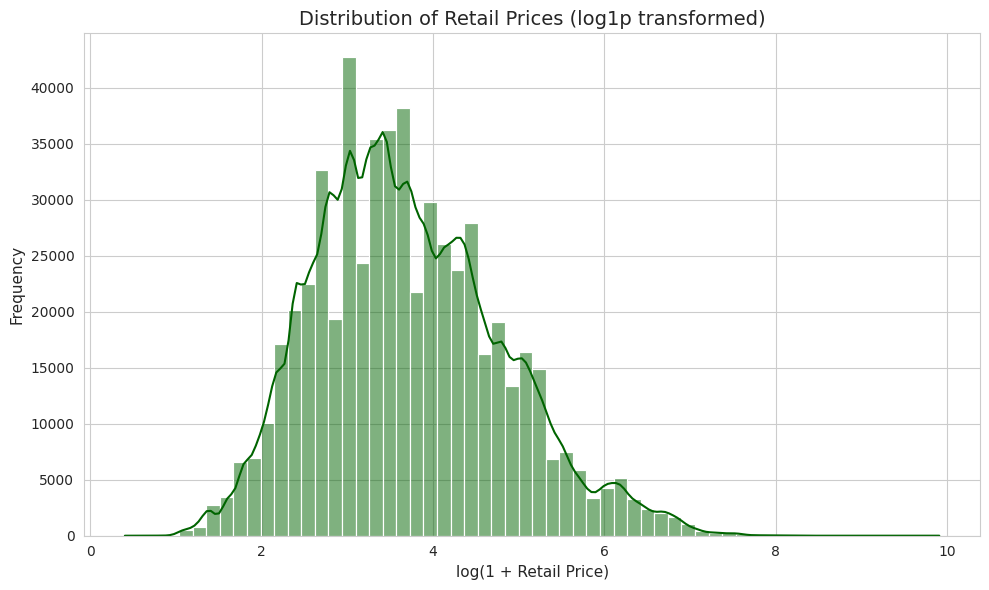

In [28]:
if "Retail Price" in analyzer.data.columns:
    priced = analyzer.data.dropna(subset=["Retail Price"])
    fig, ax = plt.subplots()
    sns.histplot(np.log1p(priced["Retail Price"]), bins=60, kde=True, color="darkgreen", ax=ax)
    ax.set_title("Distribution of Retail Prices (log1p transformed)")
    ax.set_xlabel("log(1 + Retail Price)")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [29]:
if "commodity_stats" in tables:
    monitoring_priority = tables["commodity_stats"][tables["commodity_stats"]["count"] >= 200].copy()
    monitoring_priority["volatility_rank"] = monitoring_priority["coefficient_of_variation"].rank(ascending=False)
    monitoring_priority["price_level_rank"] = monitoring_priority["mean"].rank(ascending=False)
    monitoring_priority["priority_score"] = (
        monitoring_priority["volatility_rank"] + monitoring_priority["price_level_rank"]
    )
    priority_ranked = monitoring_priority.sort_values("priority_score").head(15)
    priority_ranked[["mean", "coefficient_of_variation", "count", "priority_score"]].round(2)

In [30]:
if "state_stats" in tables:
    state_price_gap = {
        state: round(row["mean"], 2)
        for state, row in tables["state_stats"].iterrows()
    }
    highest_state = max(state_price_gap, key=state_price_gap.get)
    lowest_state = min(state_price_gap, key=state_price_gap.get)
    print(highest_state, state_price_gap[highest_state])
    print(lowest_state, state_price_gap[lowest_state])

Sikkim 132.04
Arunachal Pradesh 55.31


In [31]:
summary_report = {
    "total_records_loaded": int(analyzer.report.get("rows_loaded", 0)),
    "duplicates_removed": int(analyzer.report.get("duplicates_removed", 0)),
    "rows_after_cleaning": int(analyzer.report.get("rows_after_cleaning", 0)),
    "unique_commodities": int(analyzer.data["Commodity"].nunique()) if "Commodity" in analyzer.data.columns else None,
    "unique_states": int(analyzer.data["State"].nunique()) if "State" in analyzer.data.columns else None,
    "years_covered": (
        int(analyzer.data["Year"].min()), int(analyzer.data["Year"].max())
    ) if "Year" in analyzer.data.columns else None,
    "most_expensive_commodity": tables["commodity_stats"].sort_values("mean", ascending=False).index[0]
        if "commodity_stats" in tables else None,
    "least_expensive_commodity": tables["commodity_stats"].sort_values("mean", ascending=True).index[0]
        if "commodity_stats" in tables else None,
    "most_volatile_commodity": tables["commodity_stats"][tables["commodity_stats"]["count"] >= 200]
        .sort_values("coefficient_of_variation", ascending=False).index[0]
        if "commodity_stats" in tables else None,
    "highest_average_price_state": highest_state if "state_stats" in tables else None,
    "lowest_average_price_state": lowest_state if "state_stats" in tables else None,
    "extreme_outlier_records": int(len(outliers)) if "commodity_stats" in tables else None
}
summary_report

{'total_records_loaded': 1147446,
 'duplicates_removed': 2270,
 'rows_after_cleaning': 1137726,
 'unique_commodities': 46,
 'unique_states': 30,
 'years_covered': (2001, 2021),
 'most_expensive_commodity': 'Coffee',
 'least_expensive_commodity': 'Biscuit',
 'most_volatile_commodity': 'Gur',
 'highest_average_price_state': 'Sikkim',
 'lowest_average_price_state': 'Arunachal Pradesh',
 'extreme_outlier_records': 1671}